# Temperature Forecasting Notebook
ARIMA, SARIMA and OLS (5-year forecast)

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import statsmodels.api as sm

from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings


In [2]:
df = pd.read_csv("../../../data/clean/Yashaswi/Final_Clean/Atlantic_Climate.csv")
stations = pd.read_csv("../../../data/clean/Yashaswi/Final_Clean/dim_station_clean.csv")
df['Date/Time'] = pd.to_datetime(df['Date/Time'])

C:\Users\biauser\AppData\Local\Temp\ipykernel_17504\4007949083.py:1: DtypeWarning: Columns (0: Climate ID) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../../../data/clean/Yashaswi/Final_Clean/Atlantic_Climate.csv")


In [3]:
# Sort + set index
df = df.sort_values('Date/Time')
df.set_index('Date/Time', inplace=True)

# Select target variable
ts = df['Mean Temp (°C)']

# Aggregate across stations (IMPORTANT ✅)
ts = ts.groupby(ts.index).mean()

# Handle missing values
ts = ts.interpolate()

# Convert to monthly
ts_monthly = ts.resample('ME').mean()

# Verify data
print(ts_monthly.index.min())
print(ts_monthly.index.max())
print(len(ts_monthly))

1995-01-31 00:00:00
2025-12-31 00:00:00
372


In [4]:
train = ts_monthly[:'2022']
test = ts_monthly['2023':]

## OLS model

In [5]:
df_ols = train.to_frame(name='temp')
df_ols['t'] = np.arange(len(df_ols))

X = sm.add_constant(df_ols['t'])
ols = sm.OLS(df_ols['temp'], X).fit()

# Predict on test
ols_test_t = np.arange(len(train), len(train)+len(test))
ols_pred = ols.predict(sm.add_constant(ols_test_t))

## ARIMA MODEL

In [6]:
arima = ARIMA(train, order=(2,1,2)).fit()

arima_pred = arima.predict(start=test.index[0], end=test.index[-1])

C:\Users\biauser\anaconda3\envs\ds312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


## SARIMA MODEL

In [7]:
sarima = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
).fit()

sarima_pred = sarima.predict(start=test.index[0], end=test.index[-1])

## EVALUATION ✅ (MOST IMPORTANT)

In [8]:
def evaluate(actual, pred, name):
    print(f"\n{name}")
    print("MAE:", mean_absolute_error(actual, pred))
    print("RMSE:", np.sqrt(mean_squared_error(actual, pred)))

evaluate(test, ols_pred, "OLS")
evaluate(test, arima_pred, "ARIMA")
evaluate(test, sarima_pred, "SARIMA")


OLS
MAE: 7.476316357941921
RMSE: 8.392387061346883

ARIMA
MAE: 1.5652309180195763
RMSE: 1.9147995929660322

SARIMA
MAE: 0.9764710040270561
RMSE: 1.2408504336929047


##  PLOTS (SEPARATE COMPARISON)

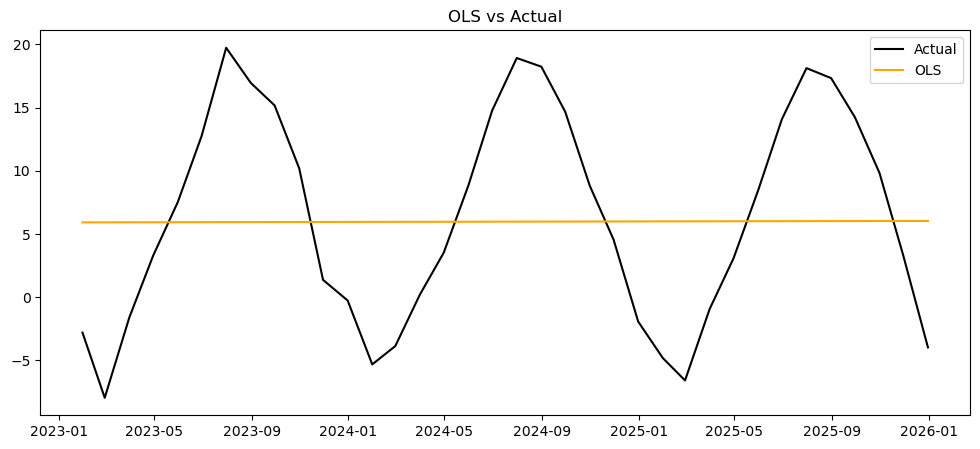

In [9]:
plt.figure(figsize=(12,5))
plt.plot(test, label="Actual", color="black")
plt.plot(test.index, ols_pred, label="OLS", color="orange")
plt.title("OLS vs Actual")
plt.legend()
plt.show()

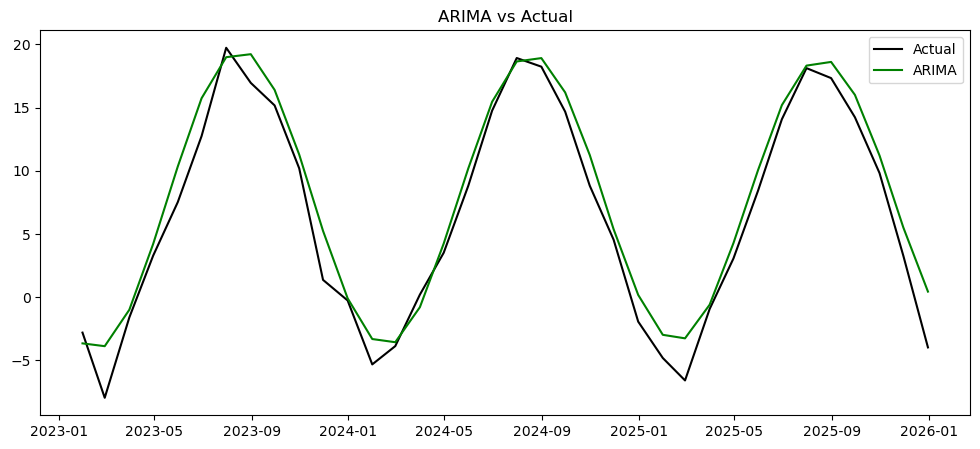

In [10]:
plt.figure(figsize=(12,5))
plt.plot(test, label="Actual", color="black")
plt.plot(test.index, arima_pred, label="ARIMA", color="green")
plt.title("ARIMA vs Actual")
plt.legend()
plt.show()

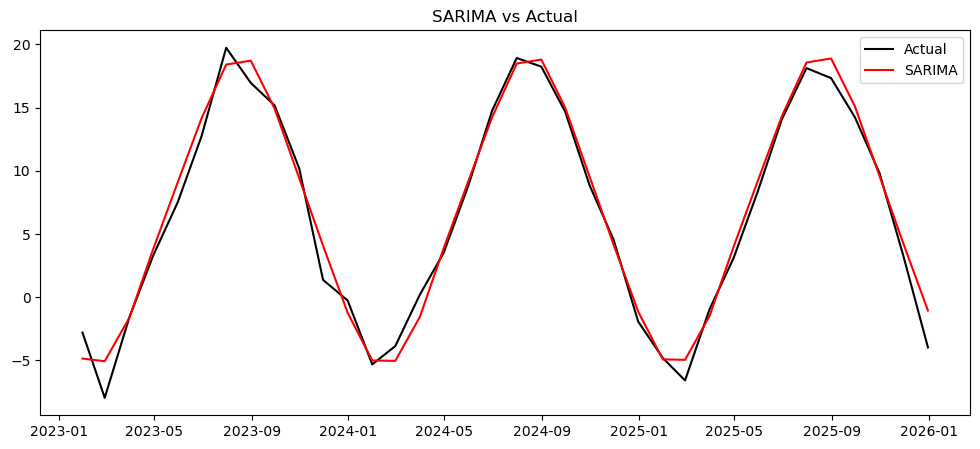

In [11]:
plt.figure(figsize=(12,5))
plt.plot(test, label="Actual", color="black")
plt.plot(test.index, sarima_pred, label="SARIMA", color="red")
plt.title("SARIMA vs Actual")
plt.legend()
plt.show()

## FUTURE FORECAST (5 YEARS)

In [12]:
future_steps = 60

future_dates = pd.date_range(
    start=ts_monthly.index[-1] + pd.offsets.MonthEnd(1),
    periods=future_steps,
    freq='ME'
)

## Forecast all models

In [13]:
# OLS
future_t = np.arange(len(ts_monthly), len(ts_monthly) + future_steps)
ols_forecast = ols.predict(sm.add_constant(future_t))

# ARIMA
arima_forecast = arima.forecast(future_steps)

# SARIMA
sarima_forecast = sarima.forecast(future_steps)

## Generate Forecast + Confidence Intervals

In [14]:
future_steps = 60

forecast = sarima.get_forecast(steps=future_steps)

# Predictions
sarima_pred = forecast.predicted_mean

# Confidence intervals
conf_int = forecast.conf_int()

 ## Create Future Dates Index

In [15]:
future_dates = pd.date_range(
    start=ts_monthly.index[-1] + pd.offsets.MonthEnd(1),
    periods=future_steps,
    freq='ME'
)

In [16]:
forecast_df = pd.DataFrame({
    "Date": future_dates,
    "SARIMA_Prediction": sarima_pred.values,
    "Lower_Bound": conf_int.iloc[:, 0].values,
    "Upper_Bound": conf_int.iloc[:, 1].values
})

In [17]:
print(forecast_df.head())

        Date  SARIMA_Prediction  Lower_Bound  Upper_Bound
0 2026-01-31          -4.853011    -7.277326    -2.428696
1 2026-02-28          -5.065203    -7.637323    -2.493083
2 2026-03-31          -1.624555    -4.243798     0.994687
3 2026-04-30           3.798418     1.147360     6.449476
4 2026-05-31           9.092572     6.413034    11.772109


## Export

In [19]:
forecast_df.to_parquet("../../../data/clean/Yashaswi/Final_Clean/sarima_forecast.parquet", index=False)

## Plot future

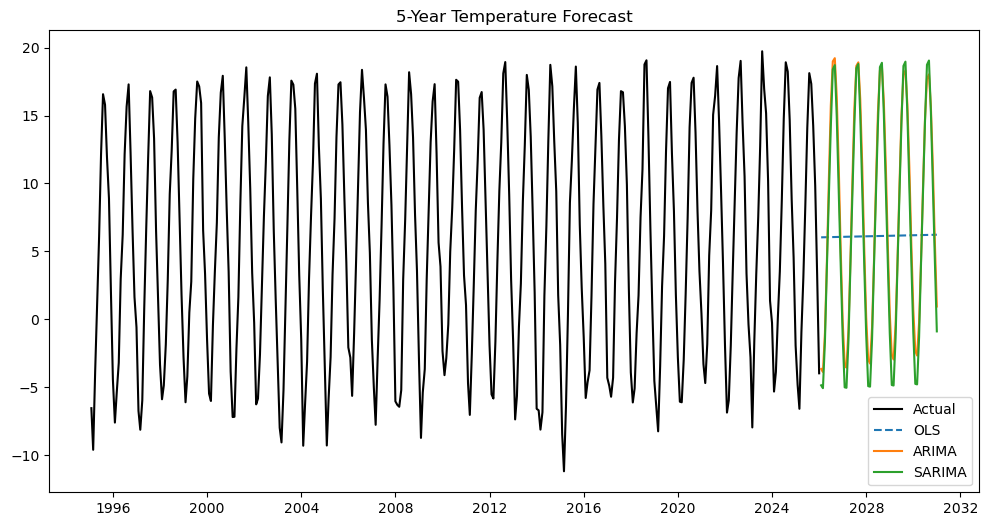

In [20]:
plt.figure(figsize=(12,6))

plt.plot(ts_monthly, label="Actual", color="black")
plt.plot(future_dates, ols_forecast, label="OLS", linestyle='dashed')
plt.plot(future_dates, arima_forecast, label="ARIMA")
plt.plot(future_dates, sarima_forecast, label="SARIMA")

plt.title("5-Year Temperature Forecast")
plt.legend()
plt.show()

## CONFIDENCE INTERVAL

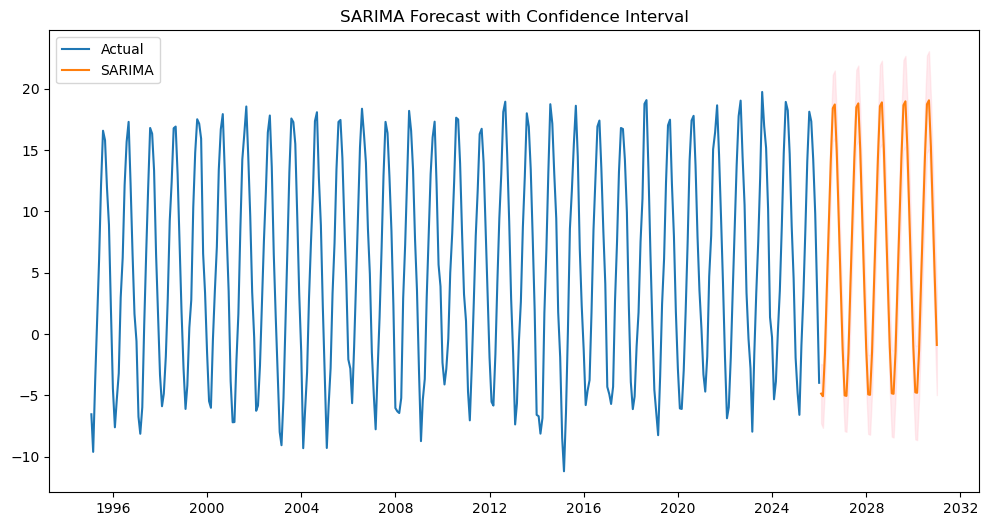

In [21]:
forecast = sarima.get_forecast(steps=future_steps)
conf_int = forecast.conf_int()

plt.figure(figsize=(12,6))

plt.plot(ts_monthly, label="Actual")
plt.plot(future_dates, sarima_forecast, label="SARIMA")

plt.fill_between(
    future_dates,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color='pink',
    alpha=0.3
)

plt.title("SARIMA Forecast with Confidence Interval")
plt.legend()
plt.show()

In [24]:
df_station.head()

,Longitude (x),Latitude (y),Station Name,Climate ID,Year,Max Temp (°C),Min Temp (°C),Mean Temp (°C),Heat Deg Days (°C),Cool Deg Days (°C),Total Rain (mm),Total Snow (cm),Total Precip (mm),Snow on Grnd (cm),Dir of Max Gust (10s deg),Spd of Max Gust (km/h)
Date/Time,,,,,,,,,,,,,,,,
1995-01-01,-62.59,58.48,SAGLEK,8503249,1995,-16.1,-23.4,-19.8,37.8,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1995-01-02,-62.59,58.48,SAGLEK,8503249,1995,-17.2,-18.9,-18.1,36.1,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1995-01-03,-62.59,58.48,SAGLEK,8503249,1995,-16.0,-18.9,-17.5,35.5,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1995-01-04,-62.59,58.48,SAGLEK,8503249,1995,-16.1,-21.1,-18.6,36.6,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1995-01-05,-62.59,58.48,SAGLEK,8503249,1995,-18.5,-21.2,-19.9,37.9,0.0,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
actual_df = ts_monthly.reset_index()
actual_df.columns = ["Date", "Actual"]

In [27]:
forecast = sarima.get_forecast(steps=60)

sarima_pred = forecast.predicted_mean
conf_int = forecast.conf_int()

In [28]:
forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Prediction": sarima_pred.values,
    "Lower": conf_int.iloc[:, 0].values,
    "Upper": conf_int.iloc[:, 1].values
})

In [29]:
# Add missing columns to actual
actual_df["Prediction"] = None
actual_df["Lower"] = None
actual_df["Upper"] = None

# Add missing column to forecast
forecast_df["Actual"] = None

# Reorder columns
actual_df = actual_df[["Date", "Actual", "Prediction", "Lower", "Upper"]]
forecast_df = forecast_df[["Date", "Actual", "Prediction", "Lower", "Upper"]]

# Combine
final_df = pd.concat([actual_df, forecast_df], ignore_index=True)

In [30]:
final_df = final_df.sort_values("Date")


In [31]:
final_df.to_parquet("../../../data/clean/Yashaswi/Final_Clean/temperature_actual_forecast.parquet", index=False)

In [32]:
final_df.head()

,Date,Actual,Prediction,Lower,Upper
0,1995-01-31,-6.536429,None,None,None
1,1995-02-28,-9.599579,None,None,None
2,1995-03-31,-3.81108,None,None,None
3,1995-04-30,1.126177,None,None,None
4,1995-05-31,6.087594,None,None,None
